In [1]:
import pandas as pd
import torch
from data_load import data_load, imshow
import matplotlib.pyplot as plt
import torchvision
import numpy as np
from train import training_loop
from inference import inference
from model import CNN
import pytorch_lightning as pl
import os



c:\Users\hozen\anaconda3\envs\chest_xray\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed set to 1



 Example Batch:


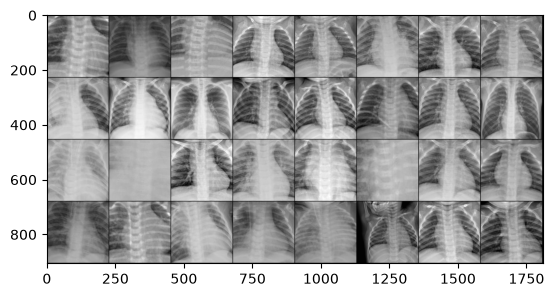

Labels:
tensor([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 0, 0])

 Start Training:


c:\Users\hozen\anaconda3\envs\chest_xray\Lib\site-packages\torchmetrics\utilities\data.py:220: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\Context.cpp:95.)
  return torch.cumsum(x, dim=dim, dtype=dtype)


Epoch 0  Average Training Loss:  0.6892, Average Validation Loss:  0.6633, Accuracy:  0.5833, Best Validation Loss:  0.6633
0.001
Epoch 1  Average Training Loss:  0.6549, Average Validation Loss:  0.6247, Accuracy:  0.7500, Best Validation Loss:  0.6247
0.001
Epoch 2  Average Training Loss:  0.6519, Average Validation Loss:  0.5865, Accuracy:  0.7500, Best Validation Loss:  0.5865
0.001
Epoch 3  Average Training Loss:  0.6016, Average Validation Loss:  0.5966, Accuracy:  0.7000, Best Validation Loss:  0.5865
0.001
Epoch 4  Average Training Loss:  0.5938, Average Validation Loss:  0.5806, Accuracy:  0.6833, Best Validation Loss:  0.5806
0.001
Epoch 5  Average Training Loss:  0.6038, Average Validation Loss:  0.5314, Accuracy:  0.7500, Best Validation Loss:  0.5314
0.001
Epoch 6  Average Training Loss:  0.5502, Average Validation Loss:  0.5484, Accuracy:  0.7500, Best Validation Loss:  0.5314
0.001
Epoch 7  Average Training Loss:  0.5679, Average Validation Loss:  0.5143, Accuracy:  0.75

In [2]:
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True, warn_only=True)

SEED = 1
pl.seed_everything(SEED, workers=True)

train_loader, val_loader, test_loader = data_load()

print("\n Example Batch:")
x, y = next(iter(train_loader))
imshow(torchvision.utils.make_grid(x))
print("Labels:")
print(y)


lr = 1e-3
num_epoch = 1000
patience= 50
factor = 0.5
print("\n Start Training:")
train_dict = training_loop(train_loader, val_loader, model = CNN(num_classes=2), lr = lr, num_epoch = num_epoch, patience= patience, factor=factor)

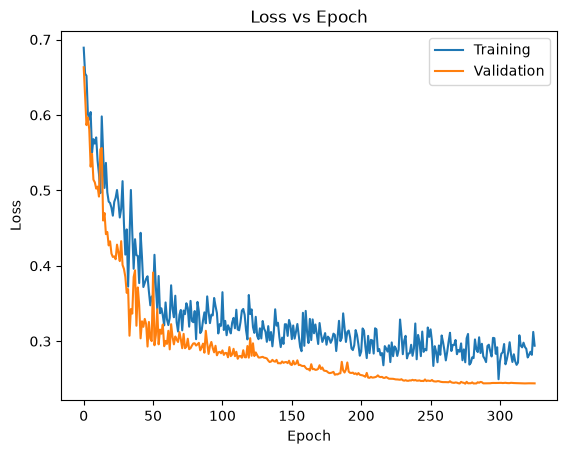

In [3]:
plt.plot(train_dict['train_loss'], label = 'Training')
plt.plot(train_dict['val_loss'], label = 'Validation')
plt.title('Loss vs Epoch')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

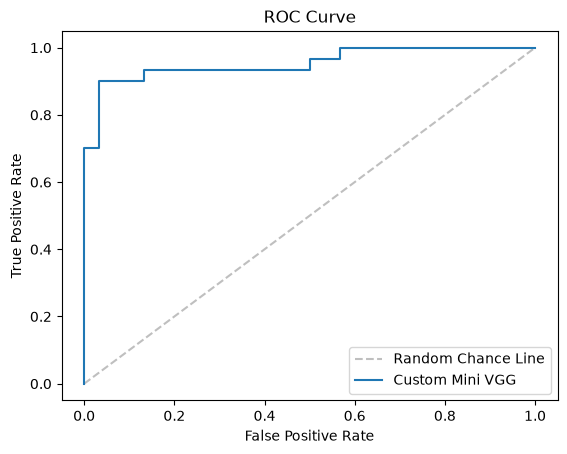

In [4]:
#ROC Curve
fpr, tpr, threshold = train_dict['roc']
fpr = fpr.cpu()
tpr = tpr.cpu()
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1),'--',color='grey',alpha=0.5, label = 'Random Chance Line')
plt.plot(fpr, tpr, label = 'Custom Mini VGG')

plt.title('ROC Curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

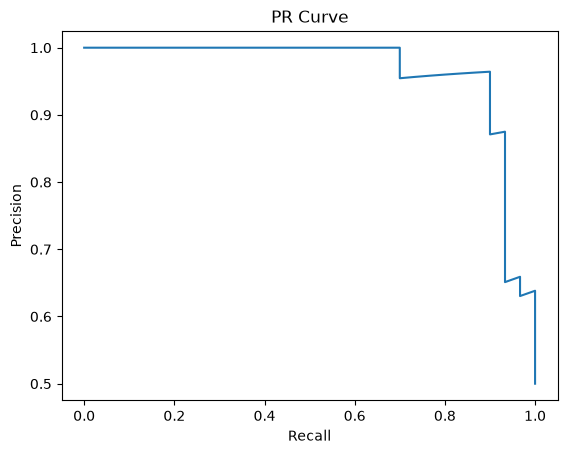

In [5]:
precision, recall, thresholds = train_dict['PR_curve']
precision = precision.cpu()
recall = recall.cpu()
plt.plot(recall, precision)
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.title('PR Curve')
plt.show()

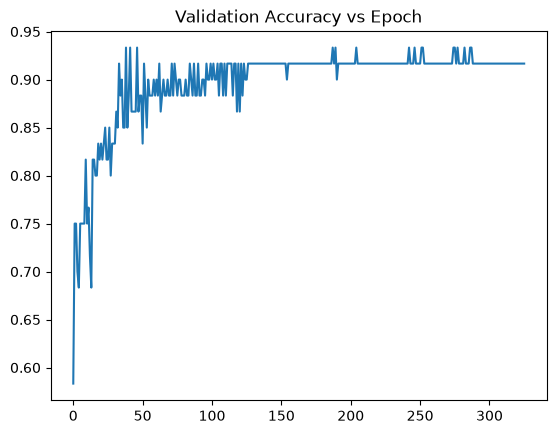

In [27]:
plt.plot(train_dict['val_acc'])
plt.title('Validation Accuracy vs Epoch')
plt.show()

In [7]:
import numpy as np
min_loss = min(train_dict['val_loss'])
min_loss_idx = np.argmin(train_dict['val_loss'])
min_loss_acc = train_dict['val_acc'][min_loss_idx]

In [30]:
filename = (
    f"../saved_models/mini_vgg"
    f"_acc_{min_loss_acc*100:.2f}"
    f"_loss_{min_loss:.4f}"
    f"_lr_{lr}"
    f"_epoches_{len(train_dict['val_loss']) - 1}"
    f"_patience_{patience}"
)
print(filename)
test_dict = inference(filename,test_loader)

../saved_models/mini_vgg_acc_93.33_loss_0.2437_lr_0.001_epoches_325_patience_50


In [25]:
test_acc = test_dict['test_acc']
print(f"Test Accuracy: {test_acc.item():.2f}")

Test Accuracy: 0.81


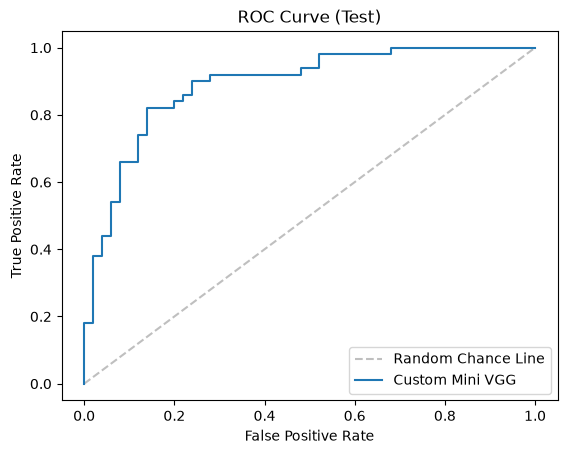

In [16]:
#ROC Curve
test_fpr,test_tpr, test_roc_threshold = test_dict['roc']
test_fpr = test_fpr.cpu()
test_tpr = test_tpr.cpu()
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1),'--',color='grey',alpha=0.5, label = 'Random Chance Line')
plt.plot(test_fpr, test_tpr, label = 'Custom Mini VGG')

plt.title('ROC Curve (Test)')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

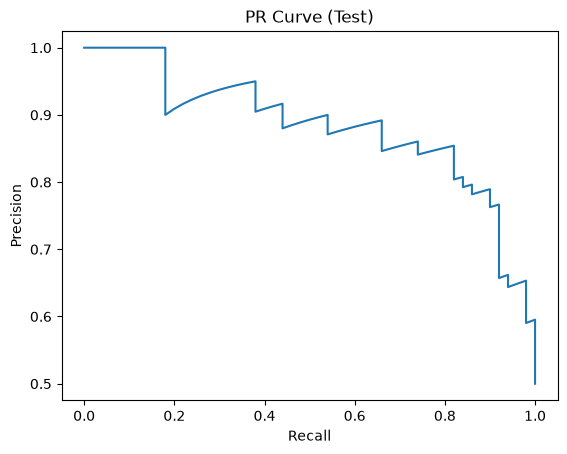

In [18]:
test_precision,test_recall, test_pr_threshold = test_dict['PR_curve']
test_precision = test_precision.cpu()
test_recall = test_recall.cpu()
plt.plot(test_recall, test_precision)
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.title('PR Curve (Test)')
plt.show()